In [ ]:
library(data.table)

process_gene_files <- function(input_dir, output_file) {
  # ---- Step 1: List CSV Files ----
  file_list <- list.files(path = input_dir, pattern = "\\.csv$", full.names = TRUE)
  if (length(file_list) == 0) {
    stop(sprintf("No CSV files found in directory '%s'.", input_dir))
  }
  
  cat("Checking for duplicate GENE_IDs in each file...\n")
  
  # ---- Step 2: Check for Duplicates (with filtering) ----
  dup_summary <- lapply(file_list, function(file) {
    dt <- fread(file)
    dt <- dt[, !grepl("^Gene", names(dt)), with = FALSE]
    dt$GENE_ID <- trimws(as.character(dt$GENE_ID))
    cat("Rows before filtering:", nrow(dt), "\n")
    cat("Rows to remove:", sum(grepl("^__", dt$GENE_ID)), "\n")
    dt <- dt[!grepl("^__", dt$GENE_ID)]
    cat("Rows after filtering:", nrow(dt), "\n")
    
    dup_count <- sum(duplicated(dt$GENE_ID))
    if (dup_count > 0) {
      message(sprintf("File: %-30s | Duplicates: %d", basename(file), dup_count))
    } else {
      message(sprintf("File: %-30s | No duplicates found.", basename(file)))
    }
    list(file = basename(file), duplicates = dup_count)
  })
  
  cat("Duplicate check complete.\n\n")
  
  # ---- Step 3: Aggregate Data by GENE_ID (with filtering) ----
  cat("Aggregating data by GENE_ID (calculating mean for each gene)...\n")
  data_list <- lapply(file_list, function(f) {
    dt <- fread(f)
    dt <- dt[, !grepl("^Gene", names(dt)), with = FALSE]
    dt$GENE_ID <- trimws(as.character(dt$GENE_ID))
    dt <- dt[!grepl("^__", dt$GENE_ID)] 

    num_cols <- names(dt)[sapply(dt, is.numeric)]
    dt_agg <- dt[, lapply(.SD, mean, na.rm = TRUE), by = GENE_ID, .SDcols = num_cols]
    cat(sprintf("Processed: %-30s | Rows after aggregation: %d\n", basename(f), nrow(dt_agg)))
    dt_agg
  })
  cat("Aggregation complete.\n\n")
  
  # ---- Step 4: Merge All Files on GENE_ID ----
  cat("Merging all aggregated data tables on GENE_ID (allowing cartesian products for duplicates)...\n")
  merged_data <- Reduce(function(x, y) {
    merge(x, y, 
          by = "GENE_ID", 
          all = TRUE, 
          allow.cartesian = TRUE)
  }, data_list)
  
  # FINAL FILTERING STEP
  merged_data$GENE_ID <- trimws(as.character(merged_data$GENE_ID))
  merged_data <- merged_data[!grepl("^__", merged_data$GENE_ID)]
  
  cat(sprintf("Merging complete. Final merged data has %d rows and %d columns.\n\n", 
              nrow(merged_data), ncol(merged_data)))
  
  # ---- Step 5: Write Output ----
  fwrite(merged_data, output_file)
  cat(sprintf("Merged dataset written to '%s'.\n", output_file))
  
  # ---- Step 6: Summary ----
  cat("\n----- Summary Report -----\n")
  cat("Files processed:\n")
  for (entry in dup_summary) {
    cat(sprintf("  %-30s | Duplicates: %d\n", entry$file, entry$duplicates))
  }
  cat(sprintf("\nFinal merged file: %s\nRows: %d\nColumns: %d\n", 
              output_file, nrow(merged_data), ncol(merged_data)))
  cat("-------------------------\n")
  
  return(merged_data)
}

In [ ]:
merged_data = process_gene_files(input_dir = "Raw/New", output_file = "Raw_Masterfile_Final.csv")

total_nas <- sum(is.na(merged_data))    
total_values <- nrow(merged_data) * ncol(merged_data)
proportion_na <- total_nas / total_values

cat("Total NAs:", total_nas, "\n")
cat("Total values:", total_values, "\n")
cat("Proportion of NAs:", proportion_na, "\n")

Checking for duplicate GENE_IDs in each file...
Rows before filtering: 60499 
Rows to remove: 0 
Rows after filtering: 60499 


File: GSE101132_genenames.csv        | Duplicates: 20333



Rows before filtering: 57260 
Rows to remove: 0 
Rows after filtering: 57260 


File: GSE104406_genenames.csv        | Duplicates: 806



Rows before filtering: 57260 
Rows to remove: 0 
Rows after filtering: 57260 


...

Rows before filtering: 22340 
Rows to remove: 0 
Rows after filtering: 22340 


File: GSE38265_gene_count_genenames.csv | No duplicates found.



Rows before filtering: 39376 
Rows to remove: 0 
Rows after filtering: 39376 


File: GSE69626_genenames_rawcounts.csv | Duplicates: 14416



Duplicate check complete.

Aggregating data by GENE_ID (calculating mean for each gene)...
Processed: GSE101132_genenames.csv        | Rows after aggregation: 40166
Processed: GSE104406_genenames.csv        | Rows after aggregation: 56454
Processed: GSE104406_label.csv            | Rows after aggregation: 56454
Processed: GSE113253.csv                  | Rows after aggregation: 1
Processed: GSE113253_AT.csv               | Rows after aggregation: 17475
Processed: GSE113253_BM.csv               | Rows after aggregation: 17475
Processed: GSE132154_genenames.csv        | Rows after aggregation: 24824
Processed: GSE139273.csv                  | Rows after aggregation: 60448
Processed: GSE139273_label.csv            | Rows after aggregation: 60448
Processed: GSE164425.csv                  | Rows after aggregation: 38692
Processed: GSE164425_label.csv            | Rows after aggregation: 38692
Processed: GSE239446_genenames_rawcounts.csv | Rows after aggregation: 61310
Processed: GSE251814_g

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Raw_Masterfile_Final.csv')
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df.to_csv('Normalized_Masterfile_Final.csv', index=False)

In [ ]:
library(edgeR)
library(sva)

normalize_and_combat <- function(folder_path) {
    
  # Step 1: List all CSV files in the folder
  files <- list.files(folder_path, pattern = "\\.csv$", full.names = TRUE)
  if (length(files) < 2) stop("Need at least 2 datasets for batch correction.")
  
  # Step 2: Read and clean each file
  count_list <- lapply(files, function(file) {
    df <- read.csv(file, check.names = FALSE)        # Don’t assign rownames yet
    df <- df[, !grepl("^Gene", names(df))]
    df <- df[!duplicated(df[[1]]), ]                 # Remove duplicated gene IDs
    df <- df[!is.na(df[[1]]) & df[[1]] != "", ]
    rownames(df) <- df[[1]]                          # Set gene IDs as rownames
    df <- df[, -1]                                   # Drop gene name column
    return(df)
  })
  
  # Step 3: Keep only common genes
  common_genes <- Reduce(intersect, lapply(count_list, rownames))
  count_list <- lapply(count_list, function(df) df[common_genes, ])


  cat("Files loaded:", length(files), "\n")
  cat("Number of common genes:", length(common_genes), "\n")

  for (i in seq_along(count_list)) {
    cat(sprintf("File %s has %d genes and %d samples after filtering.\n", 
                basename(files[i]), nrow(count_list[[i]]), ncol(count_list[[i]])))
  }

  if (length(common_genes) == 0) stop("No common genes found across all files.")

  
  # Step 4: Combine all datasets
  combined_counts <- do.call(cbind, count_list)
  
  if (any(combined_counts < 0, na.rm = TRUE)) {
    cat("Negative values found in combined_counts. Replacing with zeros.\n")
    combined_counts[combined_counts < 0] <- 0
}

  # Step 5: Create batch vector (based on file names)
  batch_labels <- rep(basename(files), sapply(count_list, ncol))
  
  # Step 6: TMM normalization (log2 CPM)
  dge <- DGEList(counts = combined_counts)
  dge <- calcNormFactors(dge, method = "TMM")
  logCPM <- cpm(dge, log = TRUE, prior.count = 1)
  
  # Step 7: Batch correction with ComBat
  combat_corrected <- ComBat(
    dat = logCPM,
    batch = factor(batch_labels),
    mod = NULL,
    par.prior = TRUE,
    prior.plots = FALSE
  )
  
  # Step 8: Return results
  return(list(
    corrected_expression = combat_corrected,
    logCPM_before_combat = logCPM,
    batch = batch_labels,
    genes = rownames(combat_corrected),
    samples = colnames(combat_corrected)
  ))
}

result <- normalize_and_combat("Raw/New")

corrected_matrix <- result$corrected_expression
head(corrected_matrix)

write.csv(corrected_matrix, "CrossPlatfromNormFinal.csv")

Loading required package: mgcv

Loading required package: nlme



This is mgcv 1.9-3. For overview type 'help("mgcv-package")'.

Loading required package: genefilter

Loading required package: BiocParallel



Files loaded: 18 
Number of common genes: 12810 
File GSE101132_genenames.csv has 12810 genes and 44 samples after filtering.
File GSE104406_genenames.csv has 12810 genes and 20 samples after filtering.
File GSE104406_label.csv has 12810 genes and 20 samples after filtering.
File GSE113253.csv has 12810 genes and 152 samples after filtering.
File GSE113253_AT.csv has 12810 genes and 42 samples after filtering.
File GSE113253_BM.csv has 12810 genes and 53 samples after filtering.
File GSE132154_genenames.csv has 12810 genes and 6 samples after filtering.
File GSE139273.csv has 12810 genes and 13 samples after filtering.
File GSE139273_label.csv has 12810 genes and 7 samples after filtering.
File GSE164425.csv has 12810 genes and 25 samples after filtering.
File GSE164425_label.csv has 12810 genes and 22 samples after filtering.
File GSE239446_genenames_rawcounts.csv has 12810 genes and 12 samples after filtering.
File GSE251814_genenames_rawcounts.csv has 12810 genes and 16 samples afte

Repeated column names found in count matrix

Found18batches

Adjusting for0covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data




,H1_Pluri_1,H1_Pluri_2,H1_Pluri_3,H1_D0_1,H1_D0_2,H1_D0_3,H1_D1_1,H1_D1_2,H1_D1_3,H1_D3_1,⋯,GSM1706730_iPSC_GSE69626,GSM1706735_iPSC_GSE69626,GSM1706740_iPSC_GSE69626,GSM1706745_iPSC_GSE69626,GSM2680626_hiPSC_GSE69626,GSM2680627_hiPSC_GSE69626,GSM2680628_hiPSC_GSE69626,GSM2680629_ESC_GSE69626,GSM2680630_ESC_GSE69626,GSM2680631_ESC_GSE69626
TSPAN6,6.1071774,5.387988,4.334903,4.2536888,3.6274347,3.724715,4.7570400,4.0750399,4.021706,7.047511,⋯,4.337299,6.128050,3.202879,4.5676552,4.113046,5.0724818,5.1333681,4.210797,4.840677,4.526766
DPM1,8.2090148,7.926726,6.761530,6.0158810,5.1727860,5.827703,8.4047978,8.4279992,7.970541,6.087887,⋯,4.451481,6.037596,3.067814,3.3648996,6.888278,6.7172255,6.6116484,7.264098,6.262269,7.178131
SCYL3,2.8488354,1.985124,1.606323,2.3609783,1.0960349,1.820294,4.0658107,2.6443147,2.560091,5.316968,⋯,5.198152,6.150159,2.405784,3.7690345,2.937720,3.0893982,2.8906527,2.960814,2.985035,3.775842
FGR,4.3389167,4.685690,4.706854,6.6756639,6.4612807,4.143551,-0.3391182,1.1386137,-3.045965,1.077463,⋯,3.358275,-5.393517,-5.393517,-0.6837134,1.456971,-0.1982263,0.5056834,2.329878,1.321350,1.411583
CFH,0.6309651,1.268724,2.477963,0.6309651,0.6309651,2.651314,0.6309651,0.6309651,1.686570,2.364815,⋯,9.218921,1.252445,1.252445,3.3599865,2.287684,2.3529440,5.5614449,6.996178,7.511064,5.518899
GCLC,8.0431699,7.724944,5.511431,5.4696111,4.2456801,5.124795,6.0432817,6.7611407,6.069217,6.234487,⋯,5.000221,6.990109,2.607749,3.4973296,4.678926,5.5773413,5.8747675,5.116773,5.129237,5.130642


In [ ]:
# def runpca_cluster(
#     df, 
#     resultpath, 
#     screeplotpath, 
#     geneclusterplotpath, 
#     n_clusters=3, 
#     n_gene_clusters=5
# ):
#     # --- 1. Preprocessing ---
#     df = df.groupby('GENE_ID', as_index=False).mean(numeric_only=True)
#     gene_ids = df.iloc[:, 0].astype('string')
#     df = df.iloc[:, 1:]
#     df.index = gene_ids
#     # Now: rows=GENES, columns=SAMPLES

#     # --- 2. Sample-centric PCA & Clustering ---
#     df_samples = df.T.astype('float64')
#     df_samples.columns = df_samples.columns.astype('string')
    
#     selector = VarianceThreshold(threshold=0.01)
#     X_reduced = selector.fit_transform(df_samples)
#     selected_genes = df_samples.columns[selector.get_support()].astype('string')

#     scaler = StandardScaler()
#     X_scaled = scaler.fit_transform(X_reduced)

#     pca = PCA(n_components=0.95)
#     X_pca = pca.fit_transform(X_scaled)
#     explained_variance_ratio = pca.explained_variance_ratio_
#     cumulative_variance = np.cumsum(explained_variance_ratio)

#     importance = np.abs(pca.components_).sum(axis=0)
#     feature_importance = pd.Series(importance, index=selected_genes)
#     top_features = feature_importance.sort_values(ascending=False).head(50)
#     top_features_df = top_features.reset_index(name='Score').rename(columns={'index':'GENE_ID'})

#     original_df = df_samples.T.reset_index().rename(columns={'index':'GENE_ID'})
#     original_df['GENE_ID'] = original_df['GENE_ID'].astype('string')
#     final_df = pd.merge(
#         original_df, 
#         top_features_df, 
#         on='GENE_ID', 
#         how='inner', 
#         validate='one_to_one'
#     )
#     final_df = final_df.sort_values('Score', ascending=False).reset_index(drop=True)
#     final_df.to_csv(resultpath, index=False)  # Only save top genes CSV

#     # --- 3. Scree Plot ---
#     plt.figure(figsize=(10, 5))
#     plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_variance, marker='o', linestyle='--')
#     plt.xlabel("Number of Principal Components")
#     plt.ylabel("Cumulative Explained Variance")
#     plt.title("PCA Scree Plot (After Feature Selection)")
#     plt.grid()
#     plt.savefig(screeplotpath, dpi=300, bbox_inches='tight')
#     plt.close()

#     # --- 4. Sample Clustering (no plot) ---
#     kmeans = KMeans(n_clusters=n_clusters, random_state=42)
#     clusters = kmeans.fit_predict(X_pca)

#     # --- 5. Gene-centric PCA & Clustering ---
#     gene_centered = df.astype('float64')  # rows=GENES, columns=SAMPLES

#     scaler_genes = StandardScaler()
#     X_genes_scaled = scaler_genes.fit_transform(gene_centered)

#     pca_genes = PCA(n_components=2)
#     X_pca_genes = pca_genes.fit_transform(X_genes_scaled)

#     kmeans_genes = KMeans(n_clusters=n_gene_clusters, random_state=42)
#     gene_clusters = kmeans_genes.fit_predict(X_pca_genes)

#     # No gene cluster CSV is saved

#     plt.figure(figsize=(12, 8))
#     ax = sns.scatterplot(x=X_pca_genes[:, 0], y=X_pca_genes[:, 1], 
#                          hue=gene_clusters, palette='tab10', legend='full')
#     # Only label top 20 genes by variance
#     top_var_genes = gene_centered.var(axis=1).sort_values(ascending=False).head(20).index
#     for i, gene_id in enumerate(gene_centered.index):
#         if gene_id in top_var_genes:
#             ax.annotate(gene_id, (X_pca_genes[i, 0], X_pca_genes[i, 1]), 
#                         xytext=(3, 3), textcoords='offset points',
#                         fontsize=7, alpha=0.8)
#     plt.xlabel('Gene PC1')
#     plt.ylabel('Gene PC2')
#     plt.title(f'Gene PCA Clusters (k={n_gene_clusters})')
#     plt.legend(title='Gene Cluster')
#     plt.grid(alpha=0.3)
#     plt.savefig(geneclusterplotpath, dpi=300, bbox_inches='tight')
#     plt.close()

#     return final_df, gene_clusters


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE
import json

def runpca_cluster(
    df, 
    resultpath, 
    screeplotpath, 
    geneclusterplotpath, 
    tsneplotpath,
    n_clusters=3, 
    n_gene_clusters=5,
    color_categories_path='Data/color_categories.json'
):
    # Ensure paths are strings
    tsneplotpath = str(tsneplotpath)
    geneclusterplotpath = str(geneclusterplotpath)
    screeplotpath = str(screeplotpath)
    resultpath = str(resultpath)
    
    print("Step 1: Loading color categories from JSON...")
    with open(color_categories_path, 'r') as f:
        color_categories = json.load(f)
    print(f"Loaded {len(color_categories)} color categories.")

    # Build gene to color and name lookup
    gene_to_color = {}
    gene_to_name = {}
    color_to_matplotlib = {
        "RED": "red",
        "NAVY BLUE": "navy",
        "LIGHT GREEN": "lightgreen",
        "ORANGE": "orange",
        "YELLOW": "yellow",
        "BROWN": "brown",
        "PURPLE": "purple",
        "DARK GREEN": "darkgreen",
        "HOT PINK": "hotpink",
        "MAGENTA": "magenta",
        "LIGHT BLUE": "lightblue",
        "BLACK": "black",
        "LIGHT PINK": "lightpink"
    }

    # Handle both dict and list JSON structures
    if isinstance(color_categories, dict):
        for color, entry in color_categories.items():
            name = entry['category']
            genes = entry['genes']
            for gene in genes:
                gene_to_color[gene] = color
                gene_to_name[gene] = name
    elif isinstance(color_categories, list):
        for entry in color_categories:
            color = entry['color']
            name = entry['name']
            genes = entry['genes']
            for gene in genes:
                gene_to_color[gene] = color
                gene_to_name[gene] = name
    else:
        raise ValueError("JSON structure not recognized.")

    print("Built gene-to-color and gene-to-name lookup tables.")

    print("Step 2: Preprocessing input dataframe...")
    df = df.groupby('GENE_ID', as_index=False).mean(numeric_only=True)
    gene_ids = df['GENE_ID'].astype('string')
    df = df.set_index(gene_ids).select_dtypes(include=np.number)
    print(f"Preprocessed dataframe: {df.shape[0]} genes, {df.shape[1]} samples.")

    print("Step 3: Sample-centric PCA & Clustering...")
    df_samples = df.T.astype('float64')
    
    selector = VarianceThreshold(threshold=0.01)
    X_reduced = selector.fit_transform(df_samples)
    selected_genes = df_samples.columns[selector.get_support()].astype('string')
    print(f"Variance thresholding: {len(selected_genes)} genes selected.")

    pipeline = make_pipeline(
        StandardScaler(),
        PCA(n_components=0.95)
    )
    X_pca = pipeline.fit_transform(X_reduced)
    pca = pipeline.named_steps['pca']
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)
    print(f"PCA complete: {X_pca.shape[1]} principal components explain 95% variance.")

    importance = np.abs(pca.components_).sum(axis=0)
    feature_importance = pd.Series(importance, index=selected_genes)
    top_features = feature_importance.nlargest(50)
    top_features_df = top_features.reset_index(name='Score').rename(columns={'index':'GENE_ID'})

    final_df = pd.merge(
        df_samples.T.reset_index().rename(columns={'index':'GENE_ID'}),
        top_features_df,
        on='GENE_ID',
        how='inner'
    ).sort_values('Score', ascending=False).reset_index(drop=True)
    final_df.to_csv(resultpath, index=False)
    print(f"Top genes saved to: {resultpath}")

    print("Step 4: Creating scree plot...")
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_variance, marker='o', linestyle='--')
    plt.xlabel("Number of Principal Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.title("PCA Scree Plot (After Feature Selection)")
    plt.grid()
    plt.savefig(screeplotpath, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Scree plot saved to: {screeplotpath}")

    print("Step 5: Sample clustering (KMeans)...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_pca)
    print(f"Sample clustering complete: {n_clusters} clusters.")

    print("Step 6: Gene-centric PCA & Clustering...")
    gene_centered = df.astype('float64')
    scaler_genes = StandardScaler()
    X_genes_scaled = scaler_genes.fit_transform(gene_centered)
    
    pca_genes = PCA(n_components=2)
    X_pca_genes = pca_genes.fit_transform(X_genes_scaled)
    
    kmeans_genes = KMeans(n_clusters=n_gene_clusters, random_state=42, n_init=10)
    gene_clusters = kmeans_genes.fit_predict(X_genes_scaled)
    print(f"Gene PCA and clustering complete: {n_gene_clusters} gene clusters.")

    print("Step 7: Running t-SNE on gene data...")
    tsne = TSNE(n_components=2, random_state=42, n_iter=1000, init='pca')
    X_tsne_genes = tsne.fit_transform(X_genes_scaled)
    print("t-SNE complete.")

    print("Step 8: Plotting gene PCA and t-SNE clusters with functional coloring...")
    gene_ids = gene_centered.index
    categories = [gene_to_name.get(gid, "Other") for gid in gene_ids]
    colors = [color_to_matplotlib.get(gene_to_color.get(gid, "LIGHT PINK"), "lightpink") for gid in gene_ids]
    
    plot_df = pd.DataFrame({
        'PC1': X_pca_genes[:, 0],
        'PC2': X_pca_genes[:, 1],
        'tSNE1': X_tsne_genes[:, 0],
        'tSNE2': X_tsne_genes[:, 1],
        'Category': categories,
        'Color': colors,
        'Gene_ID': gene_ids
    })
    
    variances = gene_centered.var(axis=1).values
    plot_df['Variance'] = variances
    top_var_genes = plot_df.nlargest(20, 'Variance')['Gene_ID'].tolist()

    # Plot PCA clusters
    plt.figure(figsize=(13, 9))
    for category, group in plot_df.groupby('Category'):
        plt.scatter(group['PC1'], group['PC2'], 
                    c=group['Color'].iloc[0],
                    s=60, 
                    edgecolor='black', 
                    alpha=0.9, 
                    zorder=2,
                    label=category)

    for _, row in plot_df[plot_df['Gene_ID'].isin(top_var_genes)].iterrows():
        plt.annotate(row['Gene_ID'], 
                    (row['PC1'], row['PC2']), 
                    xytext=(3, 3), 
                    textcoords='offset points',
                    fontsize=7, 
                    alpha=0.8, 
                    zorder=3)

    plt.xlabel('Gene PC1')
    plt.ylabel('Gene PC2')
    plt.title(f'Gene PCA Clusters (k={n_gene_clusters}) with Functional Coloring')
    plt.grid(alpha=0.3)
    unique_categories = plot_df.drop_duplicates('Category')[['Category', 'Color']]
    legend_elements = [Line2D([0], [0], marker='o', color='w', label=cat,
                              markerfacecolor=color, markersize=10, markeredgecolor='black')
                      for cat, color in unique_categories.values]
    plt.legend(
        handles=legend_elements,
        title='Gene Function',
        loc='lower center',
        bbox_to_anchor=(0.5, 1.02),
        ncol=4,  # Adjust as needed for your number of categories
        frameon=False
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for legend
    plt.savefig(geneclusterplotpath, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Gene PCA cluster plot saved to: {geneclusterplotpath}")

    # Plot t-SNE clusters
    plt.figure(figsize=(13, 9))
    for category, group in plot_df.groupby('Category'):
        plt.scatter(group['tSNE1'], group['tSNE2'], 
                    c=group['Color'].iloc[0],
                    s=60, 
                    edgecolor='black', 
                    alpha=0.9, 
                    zorder=2,
                    label=category)

    for _, row in plot_df[plot_df['Gene_ID'].isin(top_var_genes)].iterrows():
        plt.annotate(row['Gene_ID'], 
                    (row['tSNE1'], row['tSNE2']), 
                    xytext=(3, 3), 
                    textcoords='offset points',
                    fontsize=7, 
                    alpha=0.8, 
                    zorder=3)

    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.title(f'Gene t-SNE Clusters (k={n_gene_clusters}) with Functional Coloring')
    plt.grid(alpha=0.3)
    plt.legend(
        handles=legend_elements,
        title='Gene Function',
        loc='lower center',
        bbox_to_anchor=(0.5, 1.02),
        ncol=4,  # Adjust as needed
        frameon=False
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(tsneplotpath, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Gene t-SNE cluster plot saved to: {tsneplotpath}")

    print("All steps complete.")
    return final_df, gene_clusters


In [ ]:
def runpca_cluster_specific(
    df, 
    resultpath, 
    screeplotpath, 
    geneclusterplotpath, 
    tsneplotpath,
    n_clusters=3, 
    n_gene_clusters=5,
    color_categories_path='Data/color_categories.json'
):
    # Ensure paths are strings
    tsneplotpath = str(tsneplotpath)
    geneclusterplotpath = str(geneclusterplotpath)
    screeplotpath = str(screeplotpath)
    resultpath = str(resultpath)
    
    print("Step 1: Loading color categories from JSON...")
    with open(color_categories_path, 'r') as f:
        color_categories = json.load(f)
    print(f"Loaded {len(color_categories)} color categories.")

    # Build gene to color and name lookup
    gene_to_color = {}
    gene_to_name = {}
    color_to_matplotlib = {
        "RED": "red",
        "NAVY BLUE": "navy",
        "LIGHT GREEN": "lightgreen",
        "ORANGE": "orange",
        "YELLOW": "yellow",
        "BROWN": "brown",
        "PURPLE": "purple",
        "DARK GREEN": "darkgreen",
        "HOT PINK": "hotpink",
        "MAGENTA": "magenta",
        "LIGHT BLUE": "lightblue",
        "BLACK": "black",
        "LIGHT PINK": "lightpink"
    }

    # Handle both dict and list JSON structures
    if isinstance(color_categories, dict):
        for color, entry in color_categories.items():
            name = entry['category']
            genes = entry['genes']
            for gene in genes:
                gene_to_color[gene] = color
                gene_to_name[gene] = name
    elif isinstance(color_categories, list):
        for entry in color_categories:
            color = entry['color']
            name = entry['name']
            genes = entry['genes']
            for gene in genes:
                gene_to_color[gene] = color
                gene_to_name[gene] = name
    else:
        raise ValueError("JSON structure not recognized.")

    print("Built gene-to-color and gene-to-name lookup tables.")

    print("Step 2: Preprocessing input dataframe...")
    df = df.groupby('GENE_ID', as_index=False).mean(numeric_only=True)
    gene_ids = df['GENE_ID'].astype('string')
    df = df.set_index(gene_ids).select_dtypes(include=np.number)
    print(f"Preprocessed dataframe: {df.shape[0]} genes, {df.shape[1]} samples.")

    print("Step 3: Sample-centric PCA & Clustering...")
    df_samples = df.T.astype('float64')
    
    selector = VarianceThreshold(threshold=0.01)
    X_reduced = selector.fit_transform(df_samples)
    selected_genes = df_samples.columns[selector.get_support()].astype('string')
    print(f"Variance thresholding: {len(selected_genes)} genes selected.")

    pipeline = make_pipeline(
        StandardScaler(),
        PCA(n_components=0.95)
    )
    X_pca = pipeline.fit_transform(X_reduced)
    pca = pipeline.named_steps['pca']
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)
    print(f"PCA complete: {X_pca.shape[1]} principal components explain 95% variance.")

    importance = np.abs(pca.components_).sum(axis=0)
    feature_importance = pd.Series(importance, index=selected_genes)
    top_features = feature_importance.nlargest(50)
    top_features_df = top_features.reset_index(name='Score').rename(columns={'index':'GENE_ID'})

    final_df = pd.merge(
        df_samples.T.reset_index().rename(columns={'index':'GENE_ID'}),
        top_features_df,
        on='GENE_ID',
        how='inner'
    ).sort_values('Score', ascending=False).reset_index(drop=True)
    final_df.to_csv(resultpath, index=False)
    print(f"Top genes saved to: {resultpath}")

    print("Step 4: Creating scree plot...")
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_variance, marker='o', linestyle='--')
    plt.xlabel("Number of Principal Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.title("PCA Scree Plot (After Feature Selection)")
    plt.grid()
    plt.savefig(screeplotpath, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Scree plot saved to: {screeplotpath}")

    print("Step 5: Sample clustering (KMeans)...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_pca)
    print(f"Sample clustering complete: {n_clusters} clusters.")

    print("Step 6: Gene-centric PCA & Clustering...")
    all_colored_genes = set(gene_to_color.keys())
    df = df[df.index.isin(all_colored_genes)]
    gene_centered = df.astype('float64')
    scaler_genes = StandardScaler()
    X_genes_scaled = scaler_genes.fit_transform(gene_centered)
    
    pca_genes = PCA(n_components=2)
    X_pca_genes = pca_genes.fit_transform(X_genes_scaled)
    
    kmeans_genes = KMeans(n_clusters=n_gene_clusters, random_state=42, n_init=10)
    gene_clusters = kmeans_genes.fit_predict(X_genes_scaled)
    print(f"Gene PCA and clustering complete: {n_gene_clusters} gene clusters.")

    print("Step 7: Running t-SNE on gene data...")
    tsne = TSNE(n_components=2, random_state=42, n_iter=1000, init='pca')
    X_tsne_genes = tsne.fit_transform(X_genes_scaled)
    print("t-SNE complete.")

    print("Step 8: Plotting gene PCA and t-SNE clusters with functional coloring...")
    gene_ids = gene_centered.index
    categories = [gene_to_name.get(gid, "Other") for gid in gene_ids]
    colors = [color_to_matplotlib.get(gene_to_color.get(gid, "LIGHT PINK"), "lightpink") for gid in gene_ids]
    
    plot_df = pd.DataFrame({
        'PC1': X_pca_genes[:, 0],
        'PC2': X_pca_genes[:, 1],
        'tSNE1': X_tsne_genes[:, 0],
        'tSNE2': X_tsne_genes[:, 1],
        'Category': categories,
        'Color': colors,
        'Gene_ID': gene_ids
    })
    
    variances = gene_centered.var(axis=1).values
    plot_df['Variance'] = variances
    top_var_genes = plot_df.nlargest(20, 'Variance')['Gene_ID'].tolist()

    # Plot PCA clusters
    plt.figure(figsize=(13, 9))
    for category, group in plot_df.groupby('Category'):
        plt.scatter(group['PC1'], group['PC2'], 
                    c=group['Color'].iloc[0],
                    s=60, 
                    edgecolor='black', 
                    alpha=0.9, 
                    zorder=2,
                    label=category)

    for _, row in plot_df[plot_df['Gene_ID'].isin(top_var_genes)].iterrows():
        plt.annotate(row['Gene_ID'], 
                    (row['PC1'], row['PC2']), 
                    xytext=(3, 3), 
                    textcoords='offset points',
                    fontsize=7, 
                    alpha=0.8, 
                    zorder=3)

    plt.xlabel('Gene PC1')
    plt.ylabel('Gene PC2')
    plt.title(f'Gene PCA Clusters (k={n_gene_clusters}) with Functional Coloring')
    plt.grid(alpha=0.3)
    unique_categories = plot_df.drop_duplicates('Category')[['Category', 'Color']]
    legend_elements = [Line2D([0], [0], marker='o', color='w', label=cat,
                              markerfacecolor=color, markersize=10, markeredgecolor='black')
                      for cat, color in unique_categories.values]
    plt.legend(
        handles=legend_elements,
        title='Gene Function',
        loc='lower center',
        bbox_to_anchor=(0.5, 1.02),
        ncol=4,  # Adjust as needed for your number of categories
        frameon=False
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for legend
    plt.savefig(geneclusterplotpath, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Gene PCA cluster plot saved to: {geneclusterplotpath}")

    # Plot t-SNE clusters
    plt.figure(figsize=(13, 9))
    for category, group in plot_df.groupby('Category'):
        plt.scatter(group['tSNE1'], group['tSNE2'], 
                    c=group['Color'].iloc[0],
                    s=60, 
                    edgecolor='black', 
                    alpha=0.9, 
                    zorder=2,
                    label=category)

    for _, row in plot_df[plot_df['Gene_ID'].isin(top_var_genes)].iterrows():
        plt.annotate(row['Gene_ID'], 
                    (row['tSNE1'], row['tSNE2']), 
                    xytext=(3, 3), 
                    textcoords='offset points',
                    fontsize=7, 
                    alpha=0.8, 
                    zorder=3)

    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.title(f'Gene t-SNE Clusters (k={n_gene_clusters}) with Functional Coloring')
    plt.grid(alpha=0.3)
    plt.legend(
        handles=legend_elements,
        title='Gene Function',
        loc='lower center',
        bbox_to_anchor=(0.5, 1.02),
        ncol=4,  # Adjust as needed
        frameon=False
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(tsneplotpath, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Gene t-SNE cluster plot saved to: {tsneplotpath}")

    print("All steps complete.")
    return final_df, gene_clusters


In [ ]:
filepath='CrossPlatfromNorm.csv'
df = pd.read_csv(filepath)
df = df.fillna(0)
print(df.shape)
resultpath = 'CrossPlatfromNorm_features.csv'
plotpath = 'CrossPlatfromNorm_plot.png'
clusterplotpath = 'CrossPlatfromNorm_clusterplot.png'
tsneplotpath='CrossPlatfromNorm_tSNE.png'

results, clusters = runpca_cluster(df, resultpath,  plotpath, clusterplotpath, tsneplotpath)

(17873, 70)
Step 1: Loading color categories from JSON...
Loaded 13 color categories.
Built gene-to-color and gene-to-name lookup tables.
Step 2: Preprocessing input dataframe...
Preprocessed dataframe: 17873 genes, 69 samples.
Step 3: Sample-centric PCA & Clustering...
Variance thresholding: 17545 genes selected.
PCA complete: 49 principal components explain 95% variance.
Top genes saved to: CrossPlatfromNorm_features.csv
Step 4: Creating scree plot...
Scree plot saved to: CrossPlatfromNorm_plot.png
Step 5: Sample clustering (KMeans)...
Sample clustering complete: 3 clusters.
Step 6: Gene-centric PCA & Clustering...
Gene PCA and clustering complete: 5 gene clusters.
Step 7: Running t-SNE on gene data...
t-SNE complete.
Step 8: Plotting gene PCA and t-SNE clusters with functional coloring...
Gene PCA cluster plot saved to: CrossPlatfromNorm_clusterplot.png
Gene t-SNE cluster plot saved to: CrossPlatfromNorm_tSNE.png
All steps complete.


In [ ]:
filepath='CrossPlatfromNorm.csv'
df = pd.read_csv(filepath)
df = df.fillna(0)
print(df.shape)
resultpath = 'CrossPlatfromNormspecific_features.csv'
plotpath = 'CrossPlatfromNormspecific_plot.png'
clusterplotpath = 'CrossPlatfromNormspecific_clusterplot.png'
tsneplotpath='CrossPlatfromNormspecific_tSNE.png'

results, clusters = runpca_cluster_specific(df, resultpath,  plotpath, clusterplotpath, tsneplotpath)

(17873, 70)
Step 1: Loading color categories from JSON...
Loaded 13 color categories.
Built gene-to-color and gene-to-name lookup tables.
Step 2: Preprocessing input dataframe...
Preprocessed dataframe: 17873 genes, 69 samples.
Step 3: Sample-centric PCA & Clustering...
Variance thresholding: 17545 genes selected.
PCA complete: 49 principal components explain 95% variance.
Top genes saved to: CrossPlatfromNormspecific_features.csv
Step 4: Creating scree plot...
Scree plot saved to: CrossPlatfromNormspecific_plot.png
Step 5: Sample clustering (KMeans)...
Sample clustering complete: 3 clusters.
Step 6: Gene-centric PCA & Clustering...
Gene PCA and clustering complete: 5 gene clusters.
Step 7: Running t-SNE on gene data...
t-SNE complete.
Step 8: Plotting gene PCA and t-SNE clusters with functional coloring...
Gene PCA cluster plot saved to: CrossPlatfromNormspecific_clusterplot.png
Gene t-SNE cluster plot saved to: CrossPlatfromNormspecific_tSNE.png
All steps complete.


New names:
• `RNA_14dOb_AT_rep1` -> `RNA_14dOb_AT_rep1...86`
• `RNA_7dOb_AT_rep1` -> `RNA_7dOb_AT_rep1...87`
• `RNA_3dOb_AT_rep1` -> `RNA_3dOb_AT_rep1...88`
• `RNA_1dOb_AT_rep1` -> `RNA_1dOb_AT_rep1...89`
• `RNA_4hOb_AT_rep1` -> `RNA_4hOb_AT_rep1...90`
• `RNA_Msc_AT_rep1` -> `RNA_Msc_AT_rep1...91`
• `RNA_4hAd_AT_rep1` -> `RNA_4hAd_AT_rep1...92`
• `RNA_1dAd_AT_rep1` -> `RNA_1dAd_AT_rep1...93`
• `RNA_3dAd_AT_rep1` -> `RNA_3dAd_AT_rep1...94`
• `RNA_7dAd_AT_rep1` -> `RNA_7dAd_AT_rep1...95`
• `RNA_14dAd_AT_rep1` -> `RNA_14dAd_AT_rep1...96`
• `RNA_14dOb_AT_rep2` -> `RNA_14dOb_AT_rep2...97`
• `RNA_7dOb_AT_rep2` -> `RNA_7dOb_AT_rep2...98`
• `RNA_3dOb_AT_rep2` -> `RNA_3dOb_AT_rep2...99`
• `RNA_1dOb_AT_rep2` -> `RNA_1dOb_AT_rep2...100`
• `RNA_4hOb_AT_rep2` -> `RNA_4hOb_AT_rep2...101`
• `RNA_Msc_AT_rep2` -> `RNA_Msc_AT_rep2...102`
• `RNA_4hAd_AT_rep2` -> `RNA_4hAd_AT_rep2...103`
• `RNA_1dAd_AT_rep2` -> `RNA_1dAd_AT_rep2...104`
• `RNA_3dAd_AT_rep2` -> `RNA_3dAd_AT_rep2...105`
• `RNA_7dAd_AT_rep2` 

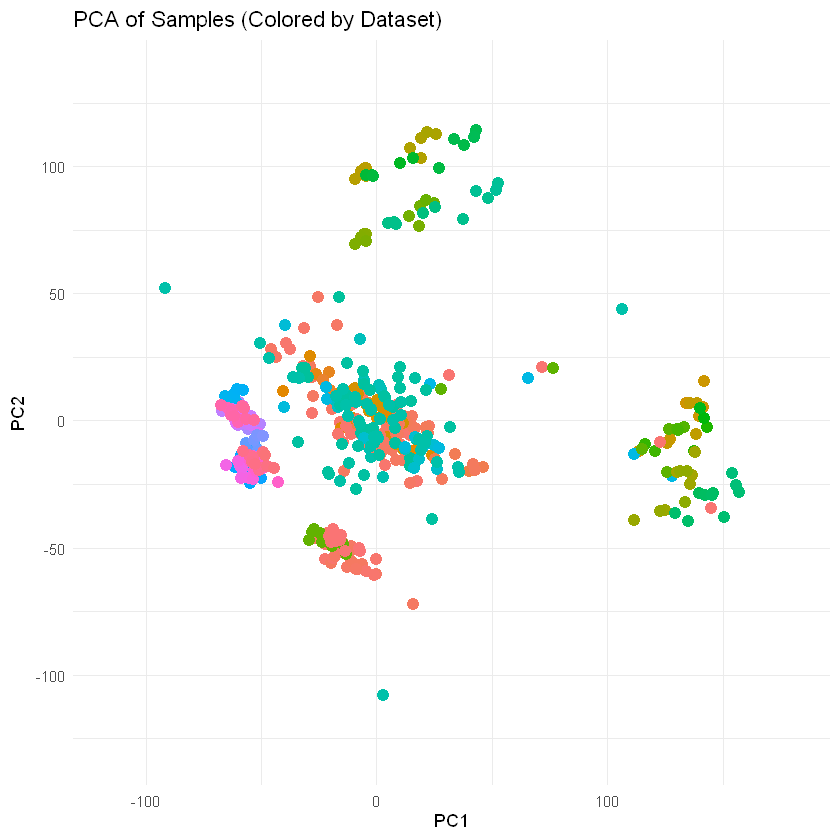

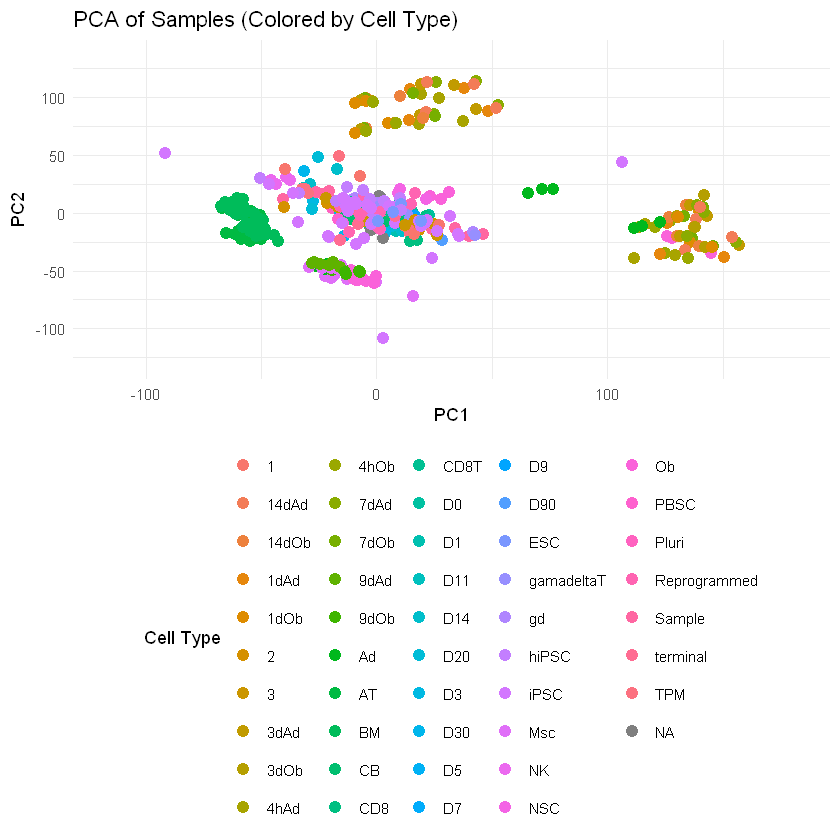

In [12]:
plot_sample_pca <- function(expr_file, gene_col = "GENE_ID", out_prefix = "CrossPlatformFinal_PCA_plot") {
  library(readr)
  library(dplyr)
  library(ggplot2)
  library(tidyr)
  
  # 1. Load data
  df <- read_csv(expr_file, show_col_types = FALSE)
  
  # 2. Remove GENE_ID column for expression matrix, keep sample columns only
  gene_names <- df[[gene_col]]
  df_samples <- df %>% select(-all_of(gene_col))
  
  # 3. Convert to matrix and set gene names as rownames
  expr_mat <- as.matrix(df_samples)
  rownames(expr_mat) <- gene_names
  
  # 4. Transpose: samples as rows, genes as columns
  expr_mat_t <- t(expr_mat)
  
  # 5. Remove samples with all NA or zero variance
  expr_mat_t <- expr_mat_t[rowSums(is.na(expr_mat_t)) < ncol(expr_mat_t), , drop = FALSE]
  expr_mat_t <- expr_mat_t[apply(expr_mat_t, 1, function(x) var(x, na.rm = TRUE) > 0), , drop = FALSE]
  
  # 6. Impute missing values (gene-wise mean)
  for(j in seq_len(ncol(expr_mat_t))) {
    nas <- is.na(expr_mat_t[, j])
    if(any(nas)) expr_mat_t[nas, j] <- mean(expr_mat_t[!nas, j], na.rm = TRUE)
  }
  
  # 7. Scale genes (columns)
  expr_scaled <- scale(expr_mat_t)
  
  # 8. Prepare sample metadata
  sample_names <- rownames(expr_scaled)
  parse_sample <- function(x) {
    parts <- unlist(strsplit(x, "_"))
    dataset <- if(length(parts) > 0) tail(parts, 1) else NA
    celltype <- if(length(parts) > 1) parts[length(parts) - 1] else NA
    data.frame(Sample = x, dataset = dataset, celltype = celltype, stringsAsFactors = FALSE)
  }
  sample_info <- bind_rows(lapply(sample_names, parse_sample))
  
  # 9. PCA
  pca <- prcomp(expr_scaled, center = TRUE, scale. = FALSE)
  pca_df <- as.data.frame(pca$x[, 1:2])
  pca_df$Sample <- rownames(expr_scaled)
  pca_df <- left_join(pca_df, sample_info, by = "Sample")
  
  # Calculate axis limits with 10% padding
  x_range <- range(pca_df$PC1, na.rm = TRUE)
  y_range <- range(pca_df$PC2, na.rm = TRUE)
  x_pad <- 0.1 * diff(x_range)
  y_pad <- 0.1 * diff(y_range)
  x_limits <- c(x_range[1] - x_pad, x_range[2] + x_pad)
  y_limits <- c(y_range[1] - y_pad, y_range[2] + y_pad)
  
  # 10. Plot by dataset
  p1 <- ggplot(pca_df, aes(x = PC1, y = PC2, color = dataset)) +
    geom_point(size = 3) +
    theme_minimal() +
    scale_x_continuous(limits = x_limits) +
    scale_y_continuous(limits = y_limits) +
    labs(title = "PCA of Samples (Colored by Dataset)", x = "PC1", y = "PC2", color = "Dataset") +
    theme(legend.position = "none")
  
  # 11. Plot by cell type
  p2 <- ggplot(pca_df, aes(x = PC1, y = PC2, color = celltype)) +
    geom_point(size = 3) +
    theme_minimal() +
    scale_x_continuous(limits = x_limits) +
    scale_y_continuous(limits = y_limits) +
    labs(title = "PCA of Samples (Colored by Cell Type)", x = "PC1", y = "PC2", color = "Cell Type") +
    theme(legend.position = "bottom")
  
  # 12. Save and print plots
  ggsave(paste0(out_prefix, "_by_dataset.png"), plot = p1, width = 40, height = 25, dpi = 300)
  ggsave(paste0(out_prefix, "_by_celltype.png"), plot = p2, width = 40, height = 25, dpi = 300)
  print(p1)
  print(p2)
}

plot_sample_pca("CrossPlatfromNormFinal.csv")

In [6]:
BiocManager::install("Rtsne")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.21 (BiocManager 1.30.26), R 4.5.1 (2025-06-13 ucrt)

Installing package(s) 'Rtsne'



package 'Rtsne' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\vivek\AppData\Local\Temp\RtmpGmm1Bp\downloaded_packages


Installation paths not writeable, unable to update packages
  path: C:/Program Files/R/R-4.5.1/library
  packages:
    boot, Matrix

Old packages: 'BiocParallel', 'DESeq2'



New names:
• `RNA_14dOb_AT_rep1` -> `RNA_14dOb_AT_rep1...86`
• `RNA_7dOb_AT_rep1` -> `RNA_7dOb_AT_rep1...87`
• `RNA_3dOb_AT_rep1` -> `RNA_3dOb_AT_rep1...88`
• `RNA_1dOb_AT_rep1` -> `RNA_1dOb_AT_rep1...89`
• `RNA_4hOb_AT_rep1` -> `RNA_4hOb_AT_rep1...90`
• `RNA_Msc_AT_rep1` -> `RNA_Msc_AT_rep1...91`
• `RNA_4hAd_AT_rep1` -> `RNA_4hAd_AT_rep1...92`
• `RNA_1dAd_AT_rep1` -> `RNA_1dAd_AT_rep1...93`
• `RNA_3dAd_AT_rep1` -> `RNA_3dAd_AT_rep1...94`
• `RNA_7dAd_AT_rep1` -> `RNA_7dAd_AT_rep1...95`
• `RNA_14dAd_AT_rep1` -> `RNA_14dAd_AT_rep1...96`
• `RNA_14dOb_AT_rep2` -> `RNA_14dOb_AT_rep2...97`
• `RNA_7dOb_AT_rep2` -> `RNA_7dOb_AT_rep2...98`
• `RNA_3dOb_AT_rep2` -> `RNA_3dOb_AT_rep2...99`
• `RNA_1dOb_AT_rep2` -> `RNA_1dOb_AT_rep2...100`
• `RNA_4hOb_AT_rep2` -> `RNA_4hOb_AT_rep2...101`
• `RNA_Msc_AT_rep2` -> `RNA_Msc_AT_rep2...102`
• `RNA_4hAd_AT_rep2` -> `RNA_4hAd_AT_rep2...103`
• `RNA_1dAd_AT_rep2` -> `RNA_1dAd_AT_rep2...104`
• `RNA_3dAd_AT_rep2` -> `RNA_3dAd_AT_rep2...105`
• `RNA_7dAd_AT_rep2` 

Performing PCA
Read the 464 x 50 data matrix successfully!
OpenMP is working. 1 threads.
Using no_dims = 2, perplexity = 30.000000, and theta = 0.500000
Computing input similarities...
Building tree...
Done in 0.05 seconds (sparsity = 0.295937)!
Learning embedding...
Iteration 50: error is 58.170122 (50 iterations in 0.03 seconds)
Iteration 100: error is 56.749115 (50 iterations in 0.03 seconds)
Iteration 150: error is 56.709412 (50 iterations in 0.03 seconds)
Iteration 200: error is 56.699509 (50 iterations in 0.03 seconds)
Iteration 250: error is 56.673985 (50 iterations in 0.03 seconds)
Iteration 300: error is 0.483298 (50 iterations in 0.02 seconds)
Iteration 350: error is 0.407741 (50 iterations in 0.02 seconds)
Iteration 400: error is 0.383244 (50 iterations in 0.02 seconds)
Iteration 450: error is 0.372281 (50 iterations in 0.02 seconds)
Iteration 500: error is 0.369887 (50 iterations in 0.03 seconds)
Iteration 550: error is 0.365178 (50 iterations in 0.02 seconds)
Iteration 600

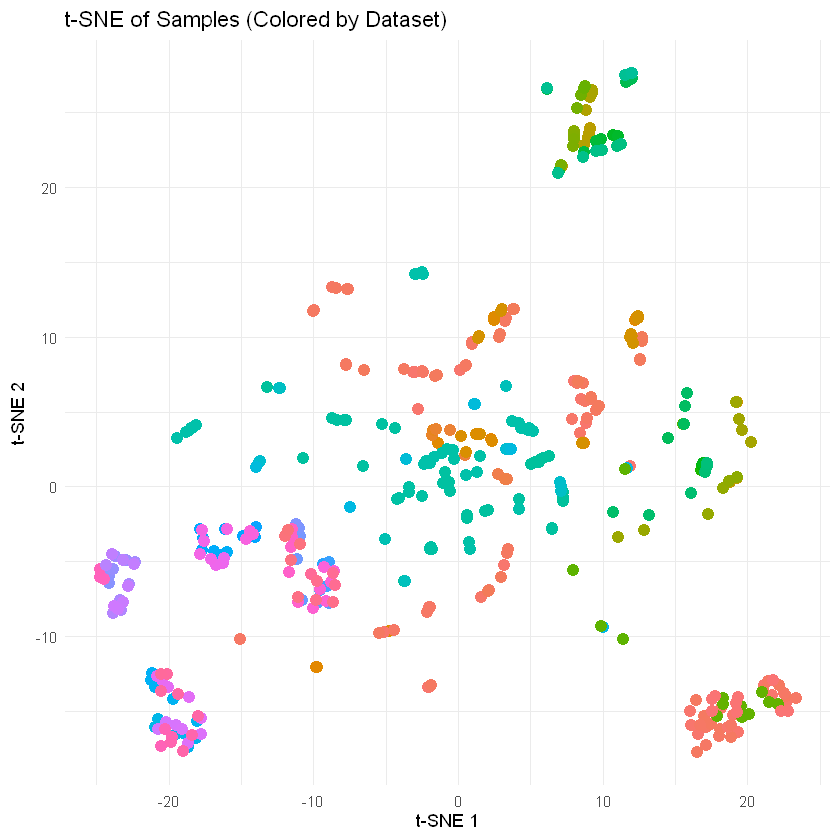

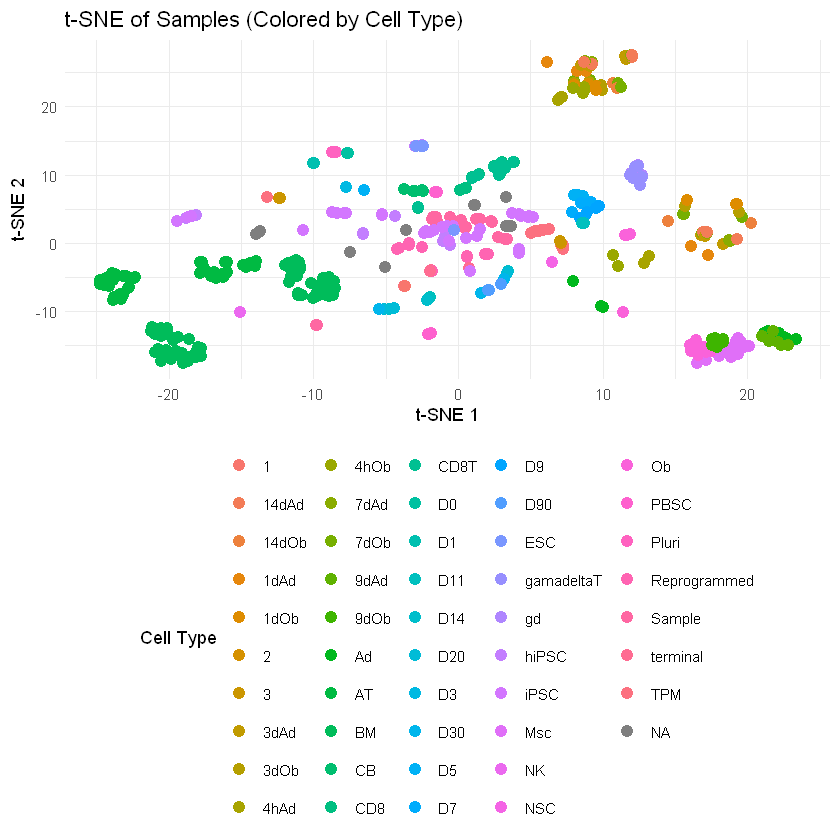

In [13]:
plot_sample_tsne <- function(expr_file, gene_col = "GENE_ID", out_prefix = "CrossPlatformFinal_tSNE_plot") {
  library(readr)
  library(dplyr)
  library(ggplot2)
  library(tidyr)
  library(Rtsne)
  
  # 1. Load data
  df <- read_csv(expr_file, show_col_types = FALSE)
  
  # 2. Extract gene names and sample expression data
  gene_names <- df[[gene_col]]
  df_samples <- df %>% select(-all_of(gene_col))
  
  # 3. Convert to matrix and set gene names as rownames
  expr_mat <- as.matrix(df_samples)
  rownames(expr_mat) <- gene_names
  
  # 4. Transpose: samples as rows, genes as columns
  expr_mat_t <- t(expr_mat)
  
  # 5. Remove samples with all NA or zero variance
  expr_mat_t <- expr_mat_t[rowSums(is.na(expr_mat_t)) < ncol(expr_mat_t), , drop = FALSE]
  expr_mat_t <- expr_mat_t[apply(expr_mat_t, 1, function(x) var(x, na.rm = TRUE) > 0), , drop = FALSE]
  
  # 6. Impute missing values (gene-wise mean)
  for(j in seq_len(ncol(expr_mat_t))) {
    nas <- is.na(expr_mat_t[, j])
    if(any(nas)) expr_mat_t[nas, j] <- mean(expr_mat_t[!nas, j], na.rm = TRUE)
  }
  
  # 7. Scale genes (columns)
  expr_scaled <- scale(expr_mat_t)
  
  # 8. Prepare sample metadata
  sample_names <- rownames(expr_scaled)
  parse_sample <- function(x) {
    parts <- unlist(strsplit(x, "_"))
    dataset <- if(length(parts) > 0) tail(parts, 1) else NA
    celltype <- if(length(parts) > 1) parts[length(parts) - 1] else NA
    data.frame(Sample = x, dataset = dataset, celltype = celltype, stringsAsFactors = FALSE)
  }
  sample_info <- bind_rows(lapply(sample_names, parse_sample))
  
  # Remove duplicate samples
  expr_scaled <- expr_scaled[!duplicated(expr_scaled), ]

  # 9. Run t-SNE
  set.seed(42)
  perplexity_value <- min(30, floor((nrow(expr_scaled) - 1) / 3))
  tsne_result <- Rtsne(expr_scaled, dims = 2, perplexity = perplexity_value, verbose = TRUE, max_iter = 1000)
  
  tsne_df <- as.data.frame(tsne_result$Y)
  names(tsne_df) <- c("tSNE1", "tSNE2")
  tsne_df$Sample <- rownames(expr_scaled)
  tsne_df <- left_join(tsne_df, sample_info, by = "Sample")
  
  # 10. Plot by dataset
  p1 <- ggplot(tsne_df, aes(x = tSNE1, y = tSNE2, color = dataset)) +
    geom_point(size = 3) +
    theme_minimal() +
    labs(title = "t-SNE of Samples (Colored by Dataset)", x = "t-SNE 1", y = "t-SNE 2", color = "Dataset") +
    theme(legend.position = "none")
  
  # 11. Plot by cell type
  p2 <- ggplot(tsne_df, aes(x = tSNE1, y = tSNE2, color = celltype)) +
    geom_point(size = 3) +
    theme_minimal() +
    labs(title = "t-SNE of Samples (Colored by Cell Type)", x = "t-SNE 1", y = "t-SNE 2", color = "Cell Type") +
    theme(legend.position = "bottom")
  
  # 12. Save and print plots
  ggsave(paste0(out_prefix, "_by_dataset.png"), plot = p1, width = 8, height = 6, dpi = 300)
  ggsave(paste0(out_prefix, "_by_celltype.png"), plot = p2, width = 8, height = 6, dpi = 300)
  print(p1)
  print(p2)
}

plot_sample_tsne("CrossPlatfromNormFinal.csv")

New names:
• `RNA_14dOb_AT_rep1` -> `RNA_14dOb_AT_rep1...86`
• `RNA_7dOb_AT_rep1` -> `RNA_7dOb_AT_rep1...87`
• `RNA_3dOb_AT_rep1` -> `RNA_3dOb_AT_rep1...88`
• `RNA_1dOb_AT_rep1` -> `RNA_1dOb_AT_rep1...89`
• `RNA_4hOb_AT_rep1` -> `RNA_4hOb_AT_rep1...90`
• `RNA_Msc_AT_rep1` -> `RNA_Msc_AT_rep1...91`
• `RNA_4hAd_AT_rep1` -> `RNA_4hAd_AT_rep1...92`
• `RNA_1dAd_AT_rep1` -> `RNA_1dAd_AT_rep1...93`
• `RNA_3dAd_AT_rep1` -> `RNA_3dAd_AT_rep1...94`
• `RNA_7dAd_AT_rep1` -> `RNA_7dAd_AT_rep1...95`
• `RNA_14dAd_AT_rep1` -> `RNA_14dAd_AT_rep1...96`
• `RNA_14dOb_AT_rep2` -> `RNA_14dOb_AT_rep2...97`
• `RNA_7dOb_AT_rep2` -> `RNA_7dOb_AT_rep2...98`
• `RNA_3dOb_AT_rep2` -> `RNA_3dOb_AT_rep2...99`
• `RNA_1dOb_AT_rep2` -> `RNA_1dOb_AT_rep2...100`
• `RNA_4hOb_AT_rep2` -> `RNA_4hOb_AT_rep2...101`
• `RNA_Msc_AT_rep2` -> `RNA_Msc_AT_rep2...102`
• `RNA_4hAd_AT_rep2` -> `RNA_4hAd_AT_rep2...103`
• `RNA_1dAd_AT_rep2` -> `RNA_1dAd_AT_rep2...104`
• `RNA_3dAd_AT_rep2` -> `RNA_3dAd_AT_rep2...105`
• `RNA_7dAd_AT_rep2` 

Performing PCA
Read the 12810 x 50 data matrix successfully!
OpenMP is working. 1 threads.
Using no_dims = 2, perplexity = 30.000000, and theta = 0.500000
Computing input similarities...
Building tree...
 - point 10000 of 12810
Done in 7.13 seconds (sparsity = 0.010820)!
Learning embedding...
Iteration 50: error is 98.711144 (50 iterations in 1.22 seconds)
Iteration 100: error is 97.398229 (50 iterations in 1.39 seconds)
Iteration 150: error is 92.174376 (50 iterations in 1.54 seconds)
Iteration 200: error is 92.022501 (50 iterations in 1.81 seconds)
Iteration 250: error is 91.978492 (50 iterations in 2.17 seconds)
Iteration 300: error is 3.892063 (50 iterations in 1.36 seconds)
Iteration 350: error is 3.610621 (50 iterations in 1.15 seconds)
Iteration 400: error is 3.457837 (50 iterations in 1.13 seconds)
Iteration 450: error is 3.355793 (50 iterations in 1.21 seconds)
Iteration 500: error is 3.282583 (50 iterations in 1.29 seconds)
Iteration 550: error is 3.226434 (50 iterations in 1

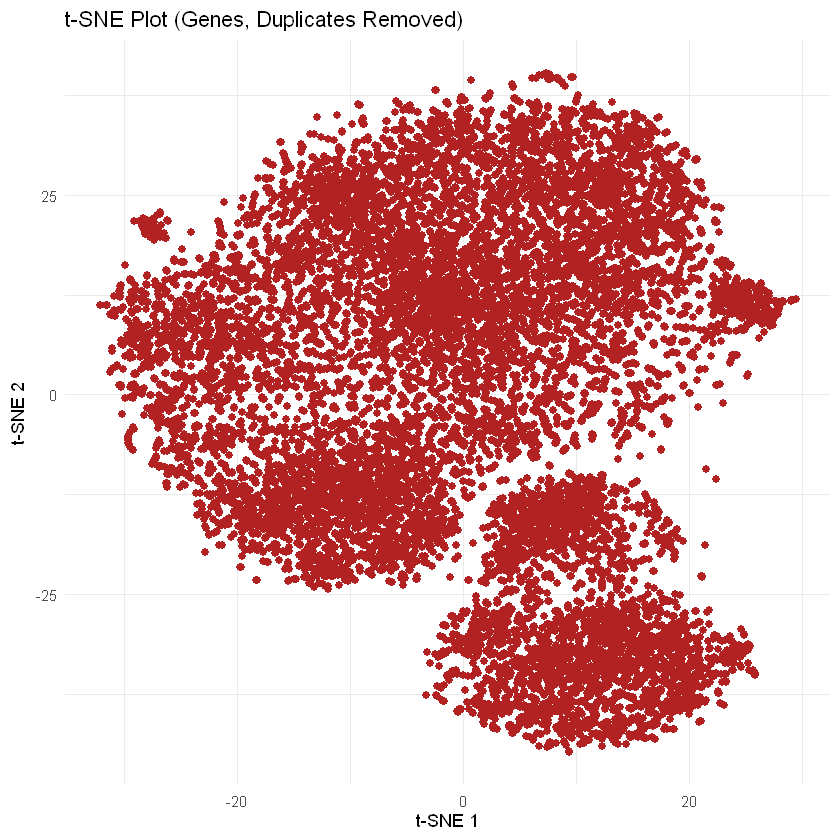

In [10]:
library(Rtsne)
library(ggplot2)
library(dplyr)
library(readr)

# Step 1: Load data
df <- read_csv("CrossPlatfromNormFinal.csv")

# Step 2: Select numeric columns (gene expression counts)
df_numeric <- df %>% select(where(is.numeric))

# Step 3: Impute missing values by gene (row-wise)
impute_with_mean <- function(x) {
  if (all(is.na(x))) {
    x[] <- 0  # Replace all-NA genes with 0
  } else {
    x[is.na(x)] <- mean(x, na.rm = TRUE)
  }
  return(x)
}
df_imputed <- t(apply(df_numeric, 1, impute_with_mean))

# Step 4: Remove genes with zero variance (constant genes)
non_constant_genes <- apply(df_imputed, 1, function(x) var(x, na.rm = TRUE) > 0)
df_filtered <- df_imputed[non_constant_genes, ]

# Step 5: Scale data (mean=0, sd=1) row-wise (genes)
df_scaled <- t(scale(t(df_filtered)))

# Step 6: Remove duplicate genes (rows)
is_duplicate <- duplicated(df_scaled)
df_scaled_nodup <- df_scaled[!is_duplicate, ]

# Update gene names to match filtered, deduplicated data
gene_names <- df$GENE_ID[non_constant_genes]
gene_names_nodup <- gene_names[!is_duplicate]

# Confirm no missing values remain
stopifnot(!any(is.na(df_scaled_nodup)))

# Step 7: Run t-SNE on deduplicated data
set.seed(42)
perplexity_value <- min(30, floor((nrow(df_scaled_nodup) - 1) / 3))
tsne_result <- Rtsne(
  df_scaled_nodup,
  dims = 2,
  perplexity = perplexity_value,
  verbose = TRUE,
  max_iter = 1000
)

# Step 8: Prepare data frame for plotting
tsne_df <- data.frame(
  TSNE1 = tsne_result$Y[, 1],
  TSNE2 = tsne_result$Y[, 2],
  Gene = gene_names_nodup
)

# Step 9: Plot t-SNE results (genes)
p <- ggplot(tsne_df, aes(x = TSNE1, y = TSNE2)) +
  geom_point(size = 2, color = "firebrick") +
  theme_minimal() +
  labs(title = "t-SNE Plot (Genes, Duplicates Removed)", x = "t-SNE 1", y = "t-SNE 2")

print(p)

# Step 10: Save the plot to a file
ggsave("CrossPlatfromNormFinal_tsne_plot.png", plot = p, width = 8, height = 6, dpi = 300)


C:\Users\ankym\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Sample cluster assignments:
GSM8422193_iPSC_GSE239446    2
GSM8422194_iPSC_GSE239446    2
GSM8422195_iPSC_GSE239446    2
GSM8422199_NSC_GSE239446     2
GSM8422200_NSC_GSE239446     2
                            ..
GSM2680627_hiPSC_GSE69626    2
GSM2680628_hiPSC_GSE69626    2
GSM2680629_ESC_GSE69626      2
GSM2680630_ESC_GSE69626      0
GSM2680631_ESC_GSE69626      2
Length: 69, dtype: int32


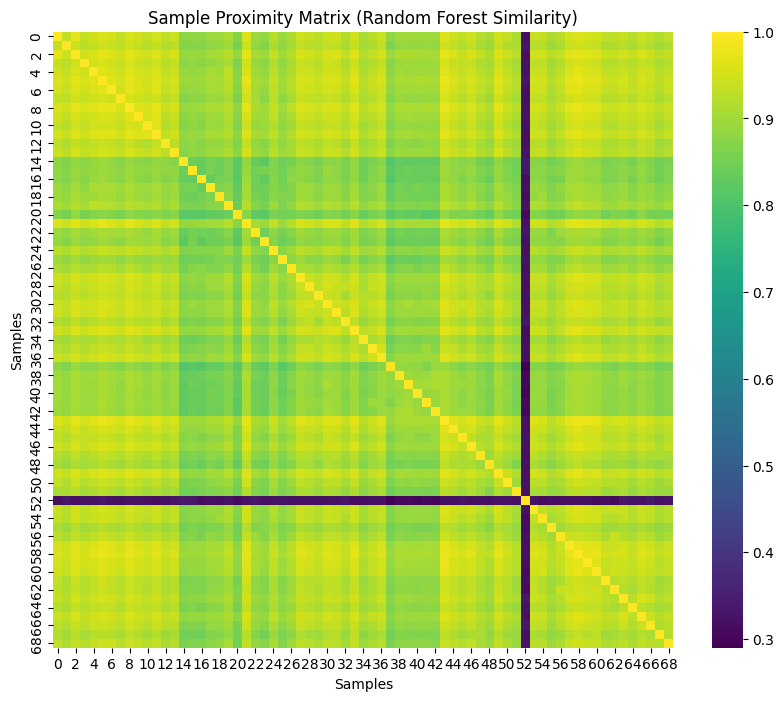

C:\Users\ankym\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\manifold\_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


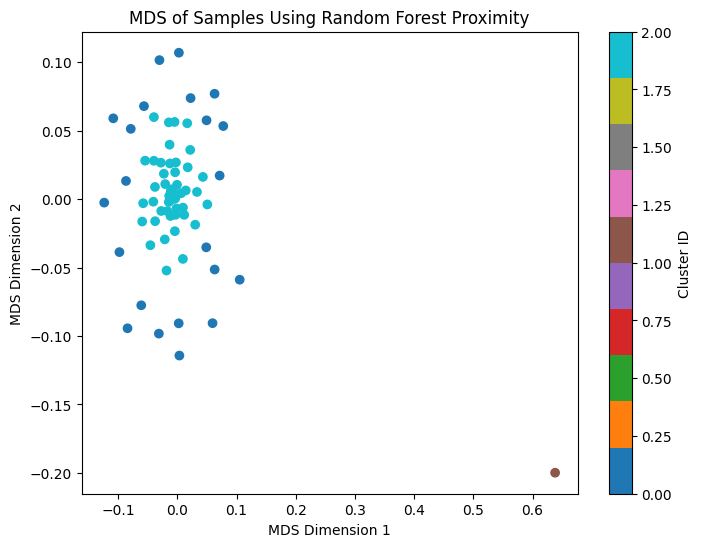

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data with genes as rows and samples as columns
df = pd.read_csv('Masterfile/CrossPlatfromNorm.csv')
df = df.set_index('GENE_ID')

# ----------------------------------
# Part 1: Unsupervised RF on Samples
# ----------------------------------

# Transpose so samples are rows, genes are columns
X_samples = df.T.values

# Standardize features (genes)
scaler_samples = StandardScaler()
X_samples_std = scaler_samples.fit_transform(X_samples)

# Generate synthetic data
X_synth_samples = np.random.normal(loc=np.mean(X_samples_std), scale=np.std(X_samples_std), size=X_samples_std.shape)

# Stack real and synthetic
X_all_samples = np.vstack([X_samples_std, X_synth_samples])
y_all_samples = np.array([1]*X_samples_std.shape[0] + [0]*X_synth_samples.shape[0])

# Train RF classifier for real vs synthetic samples
rf_samples = RandomForestClassifier(n_estimators=500, max_features='sqrt', oob_score=True, n_jobs=-1)
rf_samples.fit(X_all_samples, y_all_samples)

# Compute proximity matrix for real samples
leaves_samples = np.array([estimator.apply(X_samples_std) for estimator in rf_samples.estimators_])
n_samples = X_samples_std.shape[0]
proximity_samples = np.zeros((n_samples, n_samples))
for tree_leaves in leaves_samples:
    for i in range(n_samples):
        for j in range(i, n_samples):
            if tree_leaves[i] == tree_leaves[j]:
                proximity_samples[i, j] += 1
                if i != j:
                    proximity_samples[j, i] += 1
proximity_samples /= rf_samples.n_estimators

# Cluster samples
dissim_samples = 1 - proximity_samples
kmeans_samples = KMeans(n_clusters=3, random_state=0)
clusters_samples = kmeans_samples.fit_predict(dissim_samples)
sample_names = df.columns.values
cluster_assignments_samples = pd.Series(clusters_samples, index=sample_names)
print("Sample cluster assignments:")
print(cluster_assignments_samples)

# Visualize sample proximity matrix
plt.figure(figsize=(10, 8))
sns.heatmap(proximity_samples, cmap='viridis')
plt.title('Sample Proximity Matrix (Random Forest Similarity)')
plt.xlabel('Samples')
plt.ylabel('Samples')
plt.show()

# MDS plot of samples
mds_samples = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
mds_coords_samples = mds_samples.fit_transform(dissim_samples)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(mds_coords_samples[:, 0], mds_coords_samples[:, 1], c=clusters_samples, cmap='tab10')
plt.title('MDS of Samples Using Random Forest Proximity')
plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.colorbar(scatter, label='Cluster ID')
plt.show()

# ----------------------------------
# Part 2: Unsupervised RF on Genes
# ----------------------------------

# Use genes as rows (original df)
X_genes = df.values

# Standardize gene expression across samples
scaler_genes = StandardScaler()
X_genes_std = scaler_genes.fit_transform(X_genes)

# Generate synthetic gene data
X_synth_genes = np.random.normal(loc=np.mean(X_genes_std), scale=np.std(X_genes_std), size=X_genes_std.shape)

# Stack real and synthetic gene data
X_all_genes = np.vstack([X_genes_std, X_synth_genes])
y_all_genes = np.array([1]*X_genes_std.shape[0] + [0]*X_synth_genes.shape[0])

# Train RF classifier for genes
rf_genes = RandomForestClassifier(n_estimators=500, max_features='sqrt', oob_score=True, n_jobs=-1)
rf_genes.fit(X_all_genes, y_all_genes)

# Compute proximity matrix for real genes
leaves_genes = np.array([estimator.apply(X_genes_std) for estimator in rf_genes.estimators_])
n_genes = X_genes_std.shape[0]
proximity_genes = np.zeros((n_genes, n_genes))
for tree_leaves in leaves_genes:
    for i in range(n_genes):
        for j in range(i, n_genes):
            if tree_leaves[i] == tree_leaves[j]:
                proximity_genes[i, j] += 1
                if i != j:
                    proximity_genes[j, i] += 1
proximity_genes /= rf_genes.n_estimators

# Cluster genes
dissim_genes = 1 - proximity_genes
kmeans_genes = KMeans(n_clusters=5, random_state=0)
clusters_genes = kmeans_genes.fit_predict(dissim_genes)
gene_names = df.index.values
cluster_assignments_genes = pd.Series(clusters_genes, index=gene_names)
print("Gene cluster assignments:")
print(cluster_assignments_genes)

# Visualize gene proximity heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(proximity_genes, cmap='viridis')
plt.title('Gene Proximity Matrix (Random Forest Similarity)')
plt.xlabel('Genes')
plt.ylabel('Genes')
plt.show()

# MDS plot of genes
mds_genes = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
mds_coords_genes = mds_genes.fit_transform(dissim_genes)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(mds_coords_genes[:, 0], mds_coords_genes[:, 1], c=clusters_genes, cmap='tab10', s=10)
plt.title('MDS of Genes Using Random Forest Proximity')
plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.colorbar(scatter, label='Gene Cluster')
plt.show()

# Optional: Save cluster assignments to CSV files
cluster_assignments_samples.to_csv('sample_cluster_assignments.csv', index=True, header=['Cluster'])
cluster_assignments_genes.to_csv('gene_cluster_assignments.csv', index=True, header=['Cluster'])
